# Climate Change Slope Analysis: Decision Tree Modeling

This notebook uses a Decision Tree model to predict local climate change slope based on geographical and climatological factors.

## Overview
- **Part 1**: Load data with climatological features (automatically added by main.py)
- **Part 2**: Build decision tree model using geographical and climatological features
- **Part 3**: Generate predictions and compare with actual slopes
- **Part 4**: Visualize decision tree structure and model performance

**Note:** Make sure to run `main.py` first to generate station_data.csv with all climatological features.

## Configuration

Set the file paths for input data and output results:

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
from pathlib import Path

# Configure visualization settings
sns.set_style("darkgrid")
%matplotlib inline

In [3]:
# Configuration: File Paths
REGRIDDED_DATA_CSV = '../output/station_data_grid_5x5.csv'  # Input regridded data with grid cells
OUTPUT_DIR = './notebook_outputs/decision_tree'

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input file: {REGRIDDED_DATA_CSV}")
print(f"Output directory: {OUTPUT_DIR}")

Input file: ../output/station_data_grid_5x5.csv
Output directory: ./notebook_outputs/decision_tree


## Part 1: Data Loading & Exploration

Load the station data and explore its structure:

In [4]:
# Load the data
print(f"Loading data from '{REGRIDDED_DATA_CSV}'...")
try:
    df = pd.read_csv(REGRIDDED_DATA_CSV)
    print(f"Successfully loaded {len(df)} grid cells")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    raise

# Display basic information
print("\n--- Data Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First few rows ---")
df.head()

Loading data from '../output/station_data_grid_5x5.csv'...
Successfully loaded 673 grid cells

--- Data Shape ---
Rows: 673, Columns: 19

--- First few rows ---


,cell_id,lat_bin,lon_bin,lat_min,lat_max,lon_min,lon_max,station_count,Latitude,Longitude,Elevation,slope,intercept,r_squared,climo_temp,climo_humidity,slope_min,slope_max,slope_std
0,-90_0,-90,0,-90,-85,0,5,1,-90.000,0.0000,9999.0,0.627435,-0.200293,0.093936,-49.212839,NaN,0.627435,0.627435,0.000000
1,-75_10,-75,10,-75,-70,10,15,1,-70.767,11.8330,119.0,0.881688,-0.289942,0.226045,-10.266053,NaN,0.881688,0.881688,0.000000
2,-70_-70,-70,-70,-70,-65,-70,-65,1,-67.567,-68.1170,33.0,1.777082,-0.567918,0.204839,-4.145304,NaN,1.777082,1.777082,0.000000
3,-70_-65,-70,-65,-70,-65,-65,-60,2,-65.325,-64.3335,11.0,2.086855,-0.366507,0.242679,-3.318061,NaN,1.907084,2.266626,0.179771
4,-70_35,-70,35,-70,-65,35,40,1,-69.000,39.5830,21.0,0.654392,-0.234454,0.110408,-10.661855,NaN,0.654392,0.654392,0.000000


In [5]:
# Display data info and statistics
print("\n--- Data Types ---")
print(df.dtypes)

missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("\n--- Missing Values ---")
    print(missing_data[missing_data > 0])

print("\n--- Column Names ---")
print(df.columns.tolist())


--- Data Types ---
cell_id               str
lat_bin             int64
lon_bin             int64
lat_min             int64
lat_max             int64
lon_min             int64
lon_max             int64
station_count       int64
Latitude          float64
Longitude         float64
Elevation         float64
slope             float64
intercept         float64
r_squared         float64
climo_temp        float64
climo_humidity    float64
slope_min         float64
slope_max         float64
slope_std         float64
dtype: object

--- Missing Values ---
climo_humidity    75
dtype: int64

--- Column Names ---
['cell_id', 'lat_bin', 'lon_bin', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'station_count', 'Latitude', 'Longitude', 'Elevation', 'slope', 'intercept', 'r_squared', 'climo_temp', 'climo_humidity', 'slope_min', 'slope_max', 'slope_std']


## Part 2: Decision Tree Model Training

This section builds a decision tree model to predict climate change slope based on:
- **Features**: `climo_temp`, `climo_humidity`, `Abs_Latitude`, `Longitude`, `Elevation`
- **Target**: `slope` (local climate change trend)

In [6]:
# Define target and features
target_col = 'slope'
df['Abs_Latitude'] = df['Latitude'].abs()
feature_cols = ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation']

# Data cleaning
print("--- Data Cleaning ---")
missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing_cols:
    print(f"Error: Missing columns: {missing_cols}")
else:
    print(f"All required columns present: {feature_cols + [target_col]}")

# Drop rows with missing values
initial_count = len(df)
df_clean = df.dropna(subset=[target_col] + feature_cols)
cleaned_count = len(df_clean)

if cleaned_count < initial_count:
    print(f"Dropped {initial_count - cleaned_count} rows due to missing data")
    print(f"  Remaining records: {cleaned_count}")
else:
    print(f"No missing values in regression variables")

if cleaned_count == 0:
    print("Error: No data remaining after cleaning")
    raise ValueError("Empty dataset after cleaning")

--- Data Cleaning ---
All required columns present: ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation', 'slope']
Dropped 75 rows due to missing data
  Remaining records: 598


In [7]:
# Prepare data for decision tree
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

print(f"\n--- Decision Tree Setup ---")
print(f"Total observations: {len(y)}")
print(f"Features: {feature_cols}")
print(f"\nDependent Variable ({target_col}) Statistics:")
print(f"  Mean: {y.mean():.6f}")
print(f"  Std: {y.std():.6f}")
print(f"  Min: {y.min():.6f}")
print(f"  Max: {y.max():.6f}")

print(f"\nFeature Statistics:")
print(X.describe())


--- Decision Tree Setup ---
Total observations: 598
Features: ['climo_temp', 'climo_humidity', 'Abs_Latitude', 'Longitude', 'Elevation']

Dependent Variable (slope) Statistics:
  Mean: 1.671840
  Std: 0.638306
  Min: -0.162984
  Max: 4.441449

Feature Statistics:
       climo_temp  climo_humidity  Abs_Latitude   Longitude    Elevation
count  598.000000      598.000000    598.000000  598.000000   598.000000
mean    10.083739       70.275749     41.728975   30.675489   402.113267
std     12.022509       13.703770     18.397763   90.123744   761.530339
min    -18.880984       26.536111      1.379000 -178.088967    -2.600000
25%      0.817421       63.747917     27.539887  -57.453470    37.000000
50%     10.105293       73.256250     42.338376   42.340911   147.916667
75%     20.599436       79.582292     56.942518  107.378892   446.743939
max     29.651105       96.491667     81.600000  177.566700  9999.000000


In [8]:
# Split data into training and testing sets
print("--- Splitting Data ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

--- Splitting Data ---
Training set size: 478 (79.9%)
Testing set size: 120 (20.1%)


In [11]:
# Hyperparameter tuning to find optimal parameters
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("="*60)

# First, fit a baseline model with default parameters
print("\nFitting baseline model with default parameters...")
dt_baseline = DecisionTreeRegressor(random_state=42)
dt_baseline.fit(X_train, y_train)

y_train_pred_baseline = dt_baseline.predict(X_train)
y_test_pred_baseline = dt_baseline.predict(X_test)

train_r2_baseline = r2_score(y_train, y_train_pred_baseline)
test_r2 = r2_score(y_test, y_test_pred_baseline)
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline))
test_mae_baseline = mean_absolute_error(y_test, y_test_pred_baseline)

print(f"\n--- Baseline Model Performance ---")
print(f"  Train R²: {train_r2_baseline:.4f}")
print(f"  Test R²: {test_r2:.4f}")
print(f"  Test RMSE: {test_rmse_baseline:.6f}")
print(f"  Test MAE: {test_mae_baseline:.6f}")

# Define parameter grid to search
param_grid = {
    'max_depth': [5, 7, 10, 12, 15],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 6, 8, 10]
}

# Create base decision tree
dt_base = DecisionTreeRegressor(random_state=42)

# Perform grid search with cross-validation
print("\nSearching optimal hyperparameters using 5-fold CV...")
grid_search = GridSearchCV(
    dt_base, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,  # Use all available processors
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print(f"\n✓ Grid search complete")
print(f"\n--- Best Parameters Found ---")
print(f"  Max Depth: {grid_search.best_params_['max_depth']}")
print(f"  Min Samples Split: {grid_search.best_params_['min_samples_split']}")
print(f"  Min Samples Leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"  Best CV R² Score: {grid_search.best_score_:.4f}")

# Get the best model
best_dt_model = grid_search.best_estimator_

# Evaluate best model on test set
y_train_pred_best = best_dt_model.predict(X_train)
y_test_pred_best = best_dt_model.predict(X_test)

train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
test_mae_best = mean_absolute_error(y_test, y_test_pred_best)

print(f"\n--- Best Model Performance on Test Set ---")
print(f"  Train R²: {train_r2_best:.4f}")
print(f"  Test R²: {test_r2_best:.4f}")
print(f"  Test RMSE: {test_rmse_best:.6f}")
print(f"  Test MAE: {test_mae_best:.6f}")

# Check overfitting
overfit_ratio_best = train_r2_best / test_r2_best if test_r2_best > 0 else float('inf')
print(f"  Overfitting Ratio (Train/Test R²): {overfit_ratio_best:.2f}")
if overfit_ratio_best > 1.2:
    print("  ⚠ Model still shows some overfitting")
else:
    print("  ✓ Model generalization improved!")

# Compare with baseline model
print(f"\n--- Comparison: Baseline vs Tuned Model ---")
print(f"Baseline Model Test R²: {test_r2:.4f}")
print(f"Tuned Model Test R²: {test_r2_best:.4f}")
improvement = ((test_r2_best - test_r2) / abs(test_r2)) * 100
print(f"Improvement: {improvement:+.2f}%")

# Update global model to use the best one
dt_model = best_dt_model
y_train_pred = y_train_pred_best
y_test_pred = y_test_pred_best
train_r2 = train_r2_best
test_r2 = test_r2_best
test_rmse = test_rmse_best
test_mae = test_mae_best

print(f"\n✓ Using tuned model for subsequent analyses")


HYPERPARAMETER TUNING (GridSearchCV)

Fitting baseline model with default parameters...

--- Baseline Model Performance ---
  Train R²: 1.0000
  Test R²: 0.3220
  Test RMSE: 0.600743
  Test MAE: 0.432942

Searching optimal hyperparameters using 5-fold CV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

✓ Grid search complete

--- Best Parameters Found ---
  Max Depth: 7
  Min Samples Split: 5
  Min Samples Leaf: 6
  Best CV R² Score: 0.3894

--- Best Model Performance on Test Set ---
  Train R²: 0.7303
  Test R²: 0.4884
  Test RMSE: 0.521877
  Test MAE: 0.383089
  Overfitting Ratio (Train/Test R²): 1.50
  ⚠ Model still shows some overfitting

--- Comparison: Baseline vs Tuned Model ---
Baseline Model Test R²: 0.3220
Tuned Model Test R²: 0.4884
Improvement: +51.64%

✓ Using tuned model for subsequent analyses



FEATURE ABLATION ANALYSIS

Testing model performance with each feature removed...
Using best hyperparameters: {'max_depth': 7, 'min_samples_leaf': 6, 'min_samples_split': 5}

  Without 'climo_temp':
    R²: 0.3256 (drop: 0.1628, 33.33%)
    RMSE: 0.599173
    MAE: 0.435408

  Without 'climo_humidity':
    R²: 0.4971 (drop: -0.0087, -1.79%)
    RMSE: 0.517399
    MAE: 0.390462

  Without 'Abs_Latitude':
    R²: 0.3834 (drop: 0.1050, 21.50%)
    RMSE: 0.572920
    MAE: 0.411715

  Without 'Longitude':
    R²: 0.3110 (drop: 0.1774, 36.33%)
    RMSE: 0.605639
    MAE: 0.469822

  Without 'Elevation':
    R²: 0.5408 (drop: -0.0524, -10.73%)
    RMSE: 0.494440
    MAE: 0.349229

--- Feature Ablation Summary (sorted by importance) ---
       Feature  R² (without feature)   R² Drop  R² Drop %     RMSE      MAE
     Longitude              0.310955  0.177414  36.327869 0.605639 0.469822
    climo_temp              0.325590  0.162779  33.331185 0.599173 0.435408
  Abs_Latitude              0.383

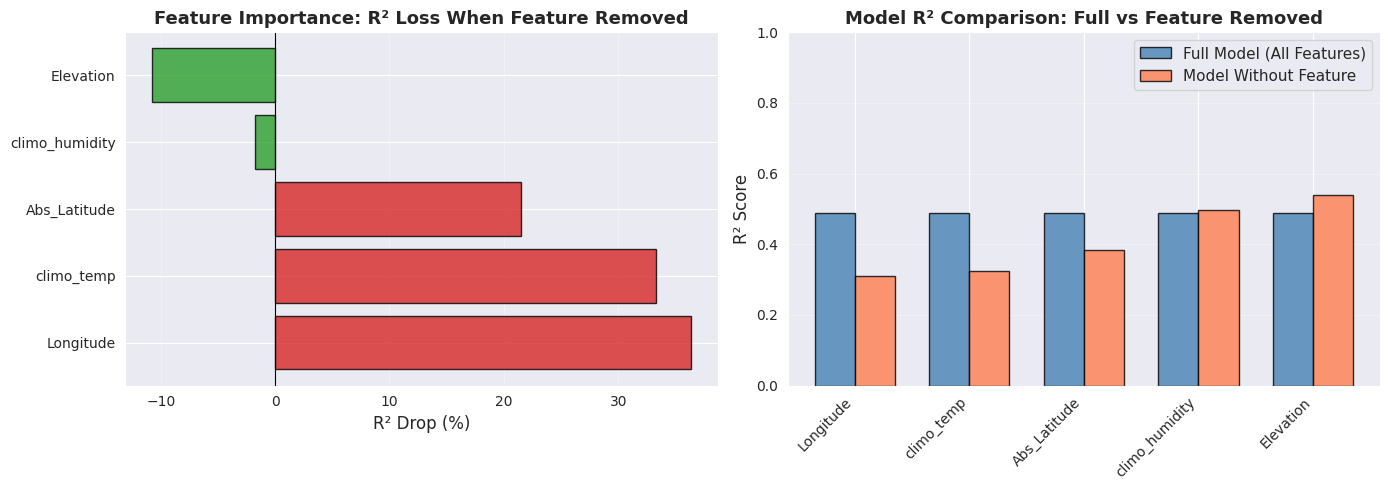


✓ Feature ablation analysis complete


In [12]:
# Feature Ablation Analysis: Remove one feature at a time
print("\n" + "="*60)
print("FEATURE ABLATION ANALYSIS")
print("="*60)
print("\nTesting model performance with each feature removed...")
print(f"Using best hyperparameters: {grid_search.best_params_}")

# Store results
ablation_results = []
full_model_r2 = test_r2_best  # R² with all features

# Test with each feature removed
for feature_to_remove in feature_cols:
    # Create feature set without current feature
    X_train_ablated = X_train.drop(columns=[feature_to_remove])
    X_test_ablated = X_test.drop(columns=[feature_to_remove])
    
    # Train model with best hyperparameters
    ablated_model = DecisionTreeRegressor(
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        random_state=42
    )
    
    ablated_model.fit(X_train_ablated, y_train)
    
    # Evaluate on test set
    y_pred_ablated = ablated_model.predict(X_test_ablated)
    ablated_r2 = r2_score(y_test, y_pred_ablated)
    ablated_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ablated))
    ablated_mae = mean_absolute_error(y_test, y_pred_ablated)
    
    # Calculate performance drop
    r2_drop = full_model_r2 - ablated_r2
    r2_drop_pct = (r2_drop / full_model_r2 * 100) if full_model_r2 > 0 else 0
    
    ablation_results.append({
        'Feature': feature_to_remove,
        'R² (without feature)': ablated_r2,
        'R² Drop': r2_drop,
        'R² Drop %': r2_drop_pct,
        'RMSE': ablated_rmse,
        'MAE': ablated_mae
    })
    
    print(f"\n  Without '{feature_to_remove}':")
    print(f"    R²: {ablated_r2:.4f} (drop: {r2_drop:.4f}, {r2_drop_pct:.2f}%)")
    print(f"    RMSE: {ablated_rmse:.6f}")
    print(f"    MAE: {ablated_mae:.6f}")

# Create DataFrame for results
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values('R² Drop %', ascending=False)

print(f"\n--- Feature Ablation Summary (sorted by importance) ---")
print(ablation_df.to_string(index=False))

# Visualization: Feature Importance via Ablation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Drop Percentage
colors = ['#d62728' if x > 5 else '#ff7f0e' if x > 2 else '#2ca02c' 
          for x in ablation_df['R² Drop %']]
axes[0].barh(ablation_df['Feature'], ablation_df['R² Drop %'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('R² Drop (%)', fontsize=12)
axes[0].set_title('Feature Importance: R² Loss When Feature Removed', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Plot 2: Absolute R² Scores
full_r2_for_plot = [full_model_r2] * len(ablation_df)
x_pos = np.arange(len(ablation_df))
width = 0.35

axes[1].bar(x_pos - width/2, full_r2_for_plot, width, label='Full Model (All Features)', 
            color='steelblue', alpha=0.8, edgecolor='black')
axes[1].bar(x_pos + width/2, ablation_df['R² (without feature)'], width, 
            label='Model Without Feature', color='coral', alpha=0.8, edgecolor='black')
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model R² Comparison: Full vs Feature Removed', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ablation_df['Feature'], rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\n✓ Feature ablation analysis complete")


## Part 3: Model Evaluation & Predictions

Evaluate the model performance and generate predictions:

In [13]:
# Make predictions on both training and test sets
print("--- Making Predictions ---")
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate metrics on training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics on test set
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n--- Training Set Performance ---")
print(f"  R² Score: {train_r2:.4f}")
print(f"  Mean Squared Error: {train_mse:.6f}")
print(f"  Root Mean Squared Error: {train_rmse:.6f}")
print(f"  Mean Absolute Error: {train_mae:.6f}")

print(f"\n--- Test Set Performance ---")
print(f"  R² Score: {test_r2:.4f}")
print(f"  Mean Squared Error: {test_mse:.6f}")
print(f"  Root Mean Squared Error: {test_rmse:.6f}")
print(f"  Mean Absolute Error: {test_mae:.6f}")

# Check for overfitting
overfit_ratio = train_r2 / test_r2 if test_r2 > 0 else float('inf')
print(f"\nOverfitting Check (Train R²/Test R²): {overfit_ratio:.2f}")
if overfit_ratio > 1.2:
    print("  ⚠ Model shows signs of overfitting")
else:
    print("  ✓ Model generalization looks good")

--- Making Predictions ---

--- Training Set Performance ---
  R² Score: 0.7303
  Mean Squared Error: 0.100879
  Root Mean Squared Error: 0.317615
  Mean Absolute Error: 0.227821

--- Test Set Performance ---
  R² Score: 0.4884
  Mean Squared Error: 0.272356
  Root Mean Squared Error: 0.521877
  Mean Absolute Error: 0.383089

Overfitting Check (Train R²/Test R²): 1.50
  ⚠ Model shows signs of overfitting



5-FOLD CROSS-VALIDATION ANALYSIS

Performing 5-fold cross-validation...

--- Cross-Validation R² Scores (5 Folds) ---
  Fold 1: Train R² = 0.7303, Test R² = 0.4884
  Fold 2: Train R² = 0.7512, Test R² = 0.2906
  Fold 3: Train R² = 0.7107, Test R² = 0.2286
  Fold 4: Train R² = 0.7177, Test R² = 0.5323
  Fold 5: Train R² = 0.7404, Test R² = 0.5028

--- Cross-Validation Summary ---
R² Scores:
  Train: Mean = 0.7301 (±0.0147)
  Test:  Mean = 0.4085 (±0.1240)

RMSE Scores:
  Mean = 0.481636 (±0.037190)

MAE Scores:
  Mean = 0.345130 (±0.033429)

--- Comparison: Single Train/Test Split vs Cross-Validation ---
Single Split Test R²:       0.5028
CV Average Test R²:         0.4085 (±0.1240)
Cross-Validation is more robust and uses all data for both training and testing.


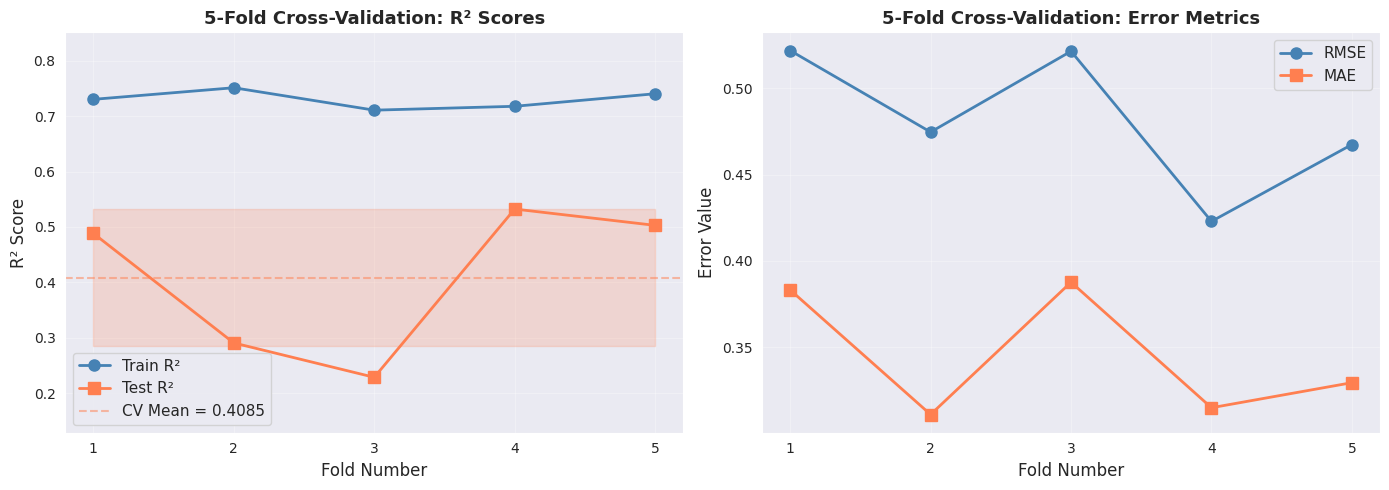


✓ Cross-validation analysis complete


In [14]:
# Perform 5-fold cross-validation
from sklearn.model_selection import cross_val_score, cross_validate, KFold

print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION ANALYSIS")
print("="*60)

# Define KFold splitter
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Create multiple scoring metrics
scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

# Perform cross-validation on full dataset
print("\nPerforming 5-fold cross-validation...")
cv_results = cross_validate(dt_model, X, y, cv=kfold, scoring=scoring, return_train_score=True)

# Extract and display results
cv_r2_train = cv_results['train_r2']
cv_r2_test = cv_results['test_r2']
cv_mse_test = -cv_results['test_neg_mse']  # Negate to get positive MSE
cv_mae_test = -cv_results['test_neg_mae']  # Negate to get positive MAE
cv_rmse_test = np.sqrt(cv_mse_test)

print(f"\n--- Cross-Validation R² Scores (5 Folds) ---")
for i, (train_r2, test_r2) in enumerate(zip(cv_r2_train, cv_r2_test), 1):
    print(f"  Fold {i}: Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}")

print(f"\n--- Cross-Validation Summary ---")
print(f"R² Scores:")
print(f"  Train: Mean = {cv_r2_train.mean():.4f} (±{cv_r2_train.std():.4f})")
print(f"  Test:  Mean = {cv_r2_test.mean():.4f} (±{cv_r2_test.std():.4f})")

print(f"\nRMSE Scores:")
print(f"  Mean = {cv_rmse_test.mean():.6f} (±{cv_rmse_test.std():.6f})")

print(f"\nMAE Scores:")
print(f"  Mean = {cv_mae_test.mean():.6f} (±{cv_mae_test.std():.6f})")

# Compare with single train/test split
print(f"\n--- Comparison: Single Train/Test Split vs Cross-Validation ---")
print(f"Single Split Test R²:       {test_r2:.4f}")
print(f"CV Average Test R²:         {cv_r2_test.mean():.4f} (±{cv_r2_test.std():.4f})")
print(f"Cross-Validation is more robust and uses all data for both training and testing.")

# Visualize CV fold results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² scores for each fold
folds = np.arange(1, 6)
axes[0].plot(folds, cv_r2_train, 'o-', label='Train R²', linewidth=2, markersize=8, color='steelblue')
axes[0].plot(folds, cv_r2_test, 's-', label='Test R²', linewidth=2, markersize=8, color='coral')
axes[0].axhline(y=cv_r2_test.mean(), color='coral', linestyle='--', alpha=0.5, label=f'CV Mean = {cv_r2_test.mean():.4f}')
axes[0].fill_between(folds, 
                     cv_r2_test.mean() - cv_r2_test.std(),
                     cv_r2_test.mean() + cv_r2_test.std(),
                     alpha=0.2, color='coral')
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('5-Fold Cross-Validation: R² Scores', fontsize=13, fontweight='bold')
axes[0].set_xticks(folds)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_ylim([cv_r2_test.min() - 0.1, cv_r2_train.max() + 0.1])

# Plot 2: Error metrics for each fold
axes[1].plot(folds, cv_rmse_test, 'o-', label='RMSE', linewidth=2, markersize=8, color='steelblue')
axes[1].plot(folds, cv_mae_test, 's-', label='MAE', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Fold Number', fontsize=12)
axes[1].set_ylabel('Error Value', fontsize=12)
axes[1].set_title('5-Fold Cross-Validation: Error Metrics', fontsize=13, fontweight='bold')
axes[1].set_xticks(folds)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Cross-validation analysis complete")

In [15]:
# Create full dataset predictions for all stations
print("\n--- Creating Full Dataset Predictions ---")
df_predictions = df_clean.copy()
df_predictions['Predicted_Slope'] = dt_model.predict(X)
df_predictions['Actual_Slope'] = y
df_predictions['Residual'] = df_predictions['Actual_Slope'] - df_predictions['Predicted_Slope']

print(f"\n--- Full Dataset Statistics ---")
print(f"\nActual Slope:")
print(f"  Mean: {df_predictions['Actual_Slope'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Actual_Slope'].std():.6f}")
print(f"  Range: [{df_predictions['Actual_Slope'].min():.6f}, {df_predictions['Actual_Slope'].max():.6f}]")

print(f"\nPredicted Slope:")
print(f"  Mean: {df_predictions['Predicted_Slope'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Predicted_Slope'].std():.6f}")
print(f"  Range: [{df_predictions['Predicted_Slope'].min():.6f}, {df_predictions['Predicted_Slope'].max():.6f}]")

print(f"\nResiduals (Actual - Predicted):")
print(f"  Mean: {df_predictions['Residual'].mean():.6f}")
print(f"  Std Dev: {df_predictions['Residual'].std():.6f}")
print(f"  Range: [{df_predictions['Residual'].min():.6f}, {df_predictions['Residual'].max():.6f}]")


--- Creating Full Dataset Predictions ---

--- Full Dataset Statistics ---

Actual Slope:
  Mean: 1.671840
  Std Dev: 0.638306
  Range: [-0.162984, 4.441449]

Predicted Slope:
  Mean: 1.664878
  Std Dev: 0.536095
  Range: [0.433462, 3.262711]

Residuals (Actual - Predicted):
  Mean: 0.006962
  Std Dev: 0.368059
  Range: [-2.312085, 1.836806]



--- Feature Importance ---
       Feature  Importance
    climo_temp    0.431532
     Longitude    0.347057
  Abs_Latitude    0.119164
     Elevation    0.081396
climo_humidity    0.020850


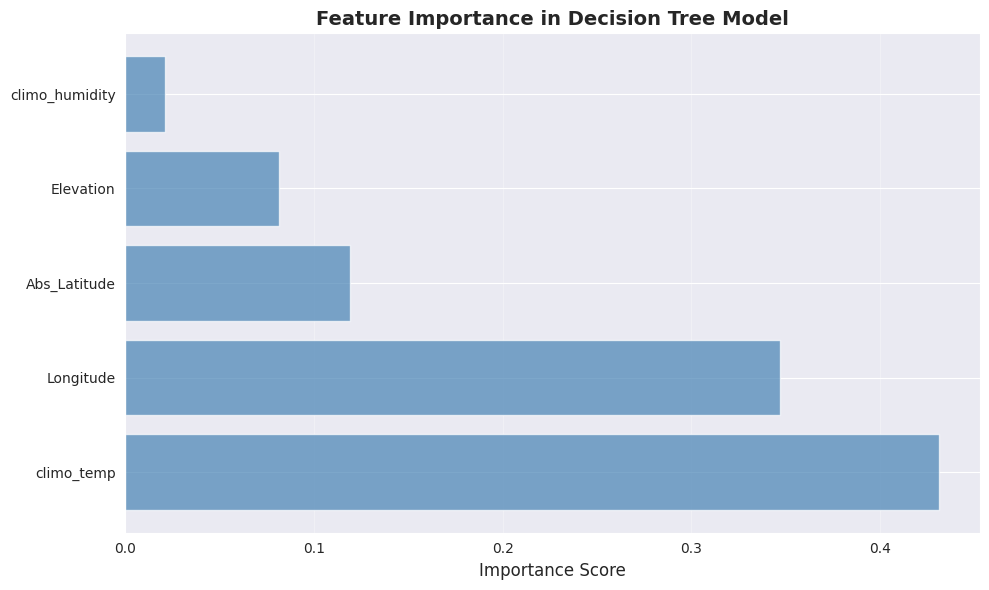

In [16]:
# Feature importance from decision tree
print("\n--- Feature Importance ---")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', alpha=0.7)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance in Decision Tree Model', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Part 4: Visualization

Visualize model performance and tree structure:

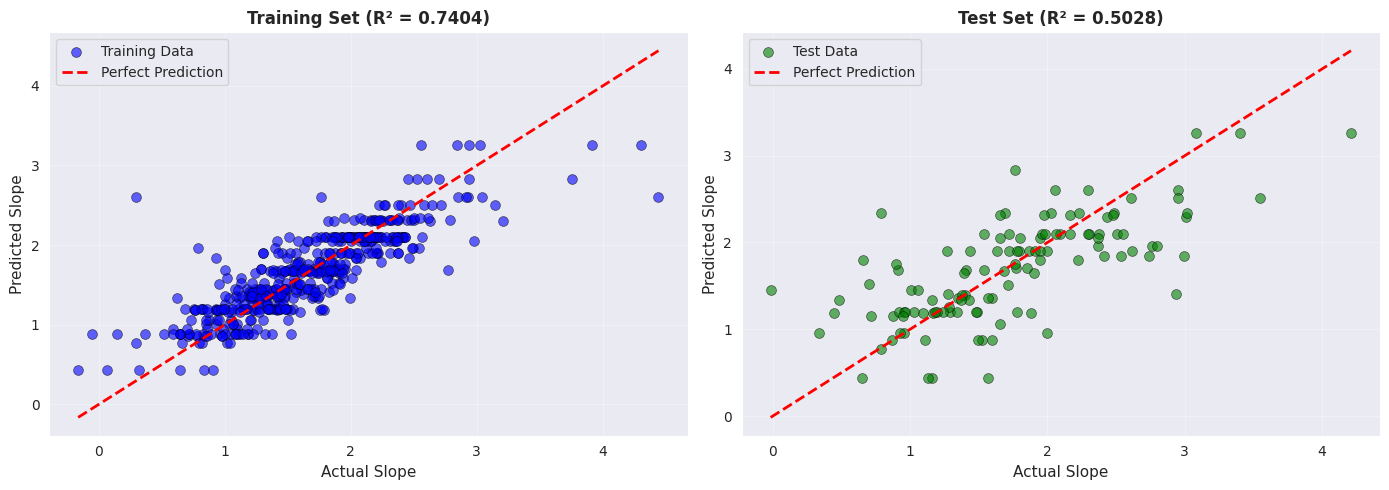

In [17]:
# Visualize: Actual vs Predicted Slopes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=50, 
               edgecolors='black', linewidth=0.5, label='Training Data')
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
            linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Slope', fontsize=11)
axes[0].set_ylabel('Predicted Slope', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Test Set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color='green', s=50, 
               edgecolors='black', linewidth=0.5, label='Test Data')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
            linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Slope', fontsize=11)
axes[1].set_ylabel('Predicted Slope', fontsize=11)
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

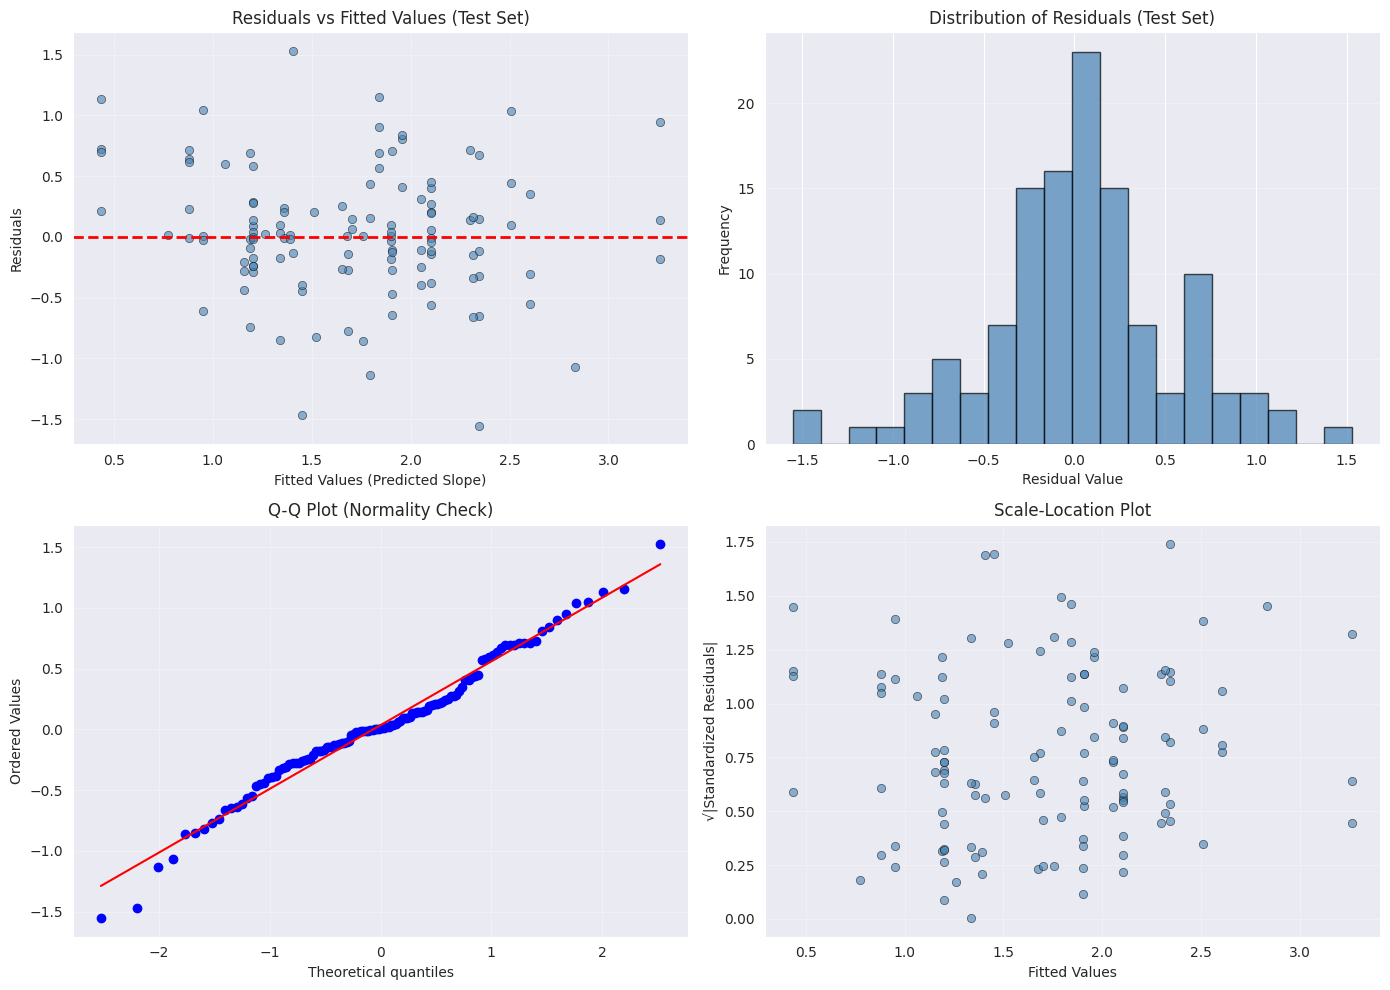

In [18]:
# Visualize: Residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(y_test_pred, y_test - y_test_pred, alpha=0.6, color='steelblue', 
                    edgecolors='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Slope)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values (Test Set)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram of Residuals
residuals_test = y_test - y_test_pred
axes[0, 1].hist(residuals_test, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals (Test Set)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scale-Location Plot
std_residuals = (residuals_test - residuals_test.mean()) / residuals_test.std()
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(std_residuals)), alpha=0.6, 
                   color='steelblue', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Visualize: Spatial Residual Map with World Map Background
import folium
from folium import plugins

# Normalize residuals for color mapping (0-1 range)
residuals = df_predictions['Residual'].values
residual_min = np.abs(residuals).max()
residual_normalized = (residuals + residual_min) / (2 * residual_min)

# Create base map centered on world
world_map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles='OpenStreetMap'
)

# Add residual points as colored markers
for idx, row in df_predictions.iterrows():
    # Color based on residual: red for negative (underestimated), blue for positive (overestimated)
    if row['Residual'] < 0:
        color = 'red'
        opacity = min(1.0, abs(row['Residual']) / residual_min)
    else:
        color = 'blue'
        opacity = min(1.0, abs(row['Residual']) / residual_min)
    
    # Create popup with station info
    popup_text = f"""
    <b>{row.get('StationName', 'Station')}</b><br>
    Actual Slope: {row['Actual_Slope']:.6f}<br>
    Predicted Slope: {row['Predicted_Slope']:.6f}<br>
    Residual: {row['Residual']:.6f}<br>
    Latitude: {row['Latitude']:.2f}<br>
    Longitude: {row['Longitude']:.2f}
    """
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=opacity,
        weight=0.5,
        opacity=0.9
    ).add_to(world_map)

# Add a title using HTML
title_html = '''
             <div style="position: fixed; 
                     top: 10px; left: 50px; width: 400px; height: 80px; 
                     background-color: white; border:2px solid grey; z-index:9999; 
                     font-size:14px; font-weight: bold; padding: 10px">
             Spatial Residual Map (with World Map)<br>
             Red = Underestimated | Blue = Overestimated<br>
             Marker opacity indicates magnitude of error
             </div>
             '''
world_map.get_root().html.add_child(folium.Element(title_html))

# Save map to HTML file
map_output_path = os.path.join(OUTPUT_DIR, 'spatial_residual_map.html')
world_map.save(map_output_path)
print(f"✓ Interactive map saved to: {map_output_path}")
print(f"  Open this file in your web browser to view the interactive map")

✓ Interactive map saved to: ./notebook_outputs/decision_tree/spatial_residual_map.html
  Open this file in your web browser to view the interactive map


## Part 5: Summary and Comparison

Summary statistics and key findings:

In [20]:
# Create summary statistics
print("\n" + "="*60)
print("DECISION TREE MODEL SUMMARY")
print("="*60)

print(f"\nModel Configuration:")
print(f"  Max Depth: {dt_model.max_depth}")
print(f"  Min Samples Split: {dt_model.min_samples_split}")
print(f"  Min Samples Leaf: {dt_model.min_samples_leaf}")

print(f"\nDataset:")
print(f"  Total Stations: {len(df_clean)}")
print(f"  Training Samples: {len(X_train)}")
print(f"  Test Samples: {len(X_test)}")

print(f"\nFeatures:")
for feat, imp in zip(feature_importance['Feature'], feature_importance['Importance']):
    print(f"  {feat}: {imp:.4f}")

print(f"\nModel Performance:")
print(f"  Test R² Score: {test_r2:.4f}")
print(f"  Test RMSE: {test_rmse:.6f}")
print(f"  Test MAE: {test_mae:.6f}")

print(f"\nResidual Analysis (Full Dataset):")
print(f"  Mean Residual: {df_predictions['Residual'].mean():.6f}")
print(f"  Std Residual: {df_predictions['Residual'].std():.6f}")
print(f"  Max Underestimate: {df_predictions['Residual'].max():.6f}")
print(f"  Max Overestimate: {df_predictions['Residual'].min():.6f}")

print("\n" + "="*60)


DECISION TREE MODEL SUMMARY

Model Configuration:
  Max Depth: 7
  Min Samples Split: 5
  Min Samples Leaf: 6

Dataset:
  Total Stations: 598
  Training Samples: 478
  Test Samples: 120

Features:
  climo_temp: 0.4315
  Longitude: 0.3471
  Abs_Latitude: 0.1192
  Elevation: 0.0814
  climo_humidity: 0.0209

Model Performance:
  Test R² Score: 0.5028
  Test RMSE: 0.521877
  Test MAE: 0.383089

Residual Analysis (Full Dataset):
  Mean Residual: 0.006962
  Std Residual: 0.368059
  Max Underestimate: 1.836806
  Max Overestimate: -2.312085



In [21]:
# Save predictions to CSV
output_csv = os.path.join(OUTPUT_DIR, 'decision_tree_predictions.csv')
output_cols = ['StationID', 'StationName', 'Latitude', 'Longitude', 'Elevation',
               'climo_temp', 'climo_humidity', 'Actual_Slope', 'Predicted_Slope', 'Residual']
final_cols = [c for c in output_cols if c in df_predictions.columns]

df_predictions[final_cols].to_csv(output_csv, index=False)
print(f"\n✓ Predictions saved to: {output_csv}")


✓ Predictions saved to: ./notebook_outputs/decision_tree/decision_tree_predictions.csv


## Part 6: Interactive Predicted Slope Map

Visualize predicted slopes from the decision tree model on an interactive world map:

In [23]:
# Import mapping libraries
import folium
from branca.colormap import linear

# Prepare data for map visualization
# Use df_clean which has the same rows as df_predictions
map_data = df_clean.copy()
map_data['Abs_Latitude'] = map_data['Latitude'].abs()
map_data['Predicted_Slope'] = df_predictions['Predicted_Slope'].values
map_data['Actual_Slope'] = df_predictions['Actual_Slope'].values

# Determine value range for colormap
value_min = float(map_data['Predicted_Slope'].min())
value_max = float(map_data['Predicted_Slope'].max())

# Scale to ensure adequate color range
if np.isclose(value_min, value_max):
    colormap = linear.YlOrRd_09.scale(value_min - 0.01, value_max + 0.01)
else:
    colormap = linear.YlOrRd_09.scale(value_min, value_max)

colormap.caption = "Predicted Climate Change Slope (Decision Tree)"

# Create the map
predicted_slope_map = folium.Map(
    location=[20.0, 0.0],
    zoom_start=2,
    tiles="CartoDB positron",
)

# Add rectangles for each grid cell
for _, row in map_data.iterrows():
    predicted_slope = float(row['Predicted_Slope'])
    actual_slope = float(row['Actual_Slope'])
    fill_color = colormap(predicted_slope)
    
    # Create popup with information
    popup_lines = [
        f"<b>Bounds:</b> [{row['lat_min']:.1f}, {row['lat_max']:.1f}) lat, [{row['lon_min']:.1f}, {row['lon_max']:.1f}) lon",
        f"<b>Station Count:</b> {int(row['station_count'])}",
        f"<b>Predicted Slope:</b> {predicted_slope:.6f}",
        f"<b>Actual Slope:</b> {actual_slope:.6f}",
        f"<b>Difference:</b> {(predicted_slope - actual_slope):.6f}",
        f"<b>Climo Temp:</b> {row.get('climo_temp', 'N/A'):.2f}",
        f"<b>Climo Humidity:</b> {row.get('climo_humidity', 'N/A'):.2f}",
        f"<b>Abs Latitude:</b> {row.get('Abs_Latitude', 'N/A'):.2f}",
    ]
    
    popup_html = "<br>".join(popup_lines)
    
    bounds = [
        [row["lat_min"], row["lon_min"]],
        [row["lat_max"], row["lon_max"]],
    ]
    
    rectangle = folium.Rectangle(
        bounds=bounds,
        stroke=False,
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"Predicted Slope: {predicted_slope:.4f} | Stations: {int(row['station_count'])}",
    )
    rectangle.add_to(predicted_slope_map)

# Add colormap to map
colormap.add_to(predicted_slope_map)

# Save map
map_output_path = f'{OUTPUT_DIR}/predicted_slopes_map.html'
predicted_slope_map.save(map_output_path)
print(f"✓ Predicted slope map saved to: {map_output_path}")

# Display the map
predicted_slope_map

✓ Predicted slope map saved to: ./notebook_outputs/decision_tree/predicted_slopes_map.html
